In [1]:
## Import libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Load dataset
data_churn=pd.read_csv(
    r"C:\Users\USER\Analytics Projects\Customer Churn Prediction (Power BI + ML)\Customer-Churn-Records.csv",
    encoding='utf-8-sig'  
)

In [3]:
data_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
data_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

## Data Cleaning

In [5]:
#Missing Values
data_churn.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [6]:
#Duplicate Check
data_churn.duplicated().sum()

np.int64(0)

In [7]:
#Remove Unnecessary
churn_clean = data_churn.copy()

churn_clean.drop(
    columns=[
        "RowNumber",
        "CustomerId",
        "Surname"
    ],
    inplace=True
)

## Check Churn Distribution


In [8]:
churn_count = data_churn["Exited"].value_counts()

print(churn_count)


Exited
0    7962
1    2038
Name: count, dtype: int64


In [9]:
churn_percent = data_churn["Exited"].value_counts(normalize=True) * 100

print(churn_percent)

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


**Churn Distribution Analysis**
- Approximately **20%** of customers have exited the bank.
- Around **80%** remain active customers.
- The bank loses roughly 1 out of every 5 customers.
- This represents a significant retention challenge and justifies the need for predictive analytics.

**Complaint vs Churn Crosstab**

In [10]:
pd.crosstab(
    data_churn["Complain"],
    data_churn["Exited"]
)

Exited,0,1
Complain,,
0,7952,4
1,10,2034


**Complaint vs Churn Bar Chart**

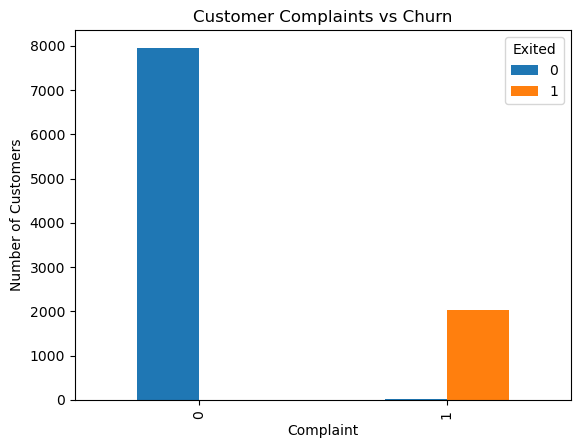

In [11]:
pd.crosstab(
    data_churn["Complain"],
    data_churn["Exited"]
).plot(kind="bar")

plt.title("Customer Complaints vs Churn")
plt.xlabel("Complaint")
plt.ylabel("Number of Customers")
plt.savefig(
    "Visuals/Customer_Complaints_vs_Churn.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

**Churn by Gender**

In [12]:
gender_churn = pd.crosstab(data_churn['Gender'], data_churn['Exited'])

print(gender_churn)



Exited     0     1
Gender            
Female  3404  1139
Male    4558   899


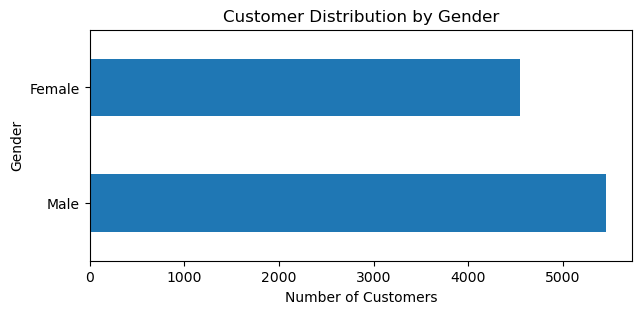

In [13]:
gender_count = data_churn["Gender"].value_counts()

gender_count.plot(
    kind="barh",
    figsize=(7,3)
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Number of Customers")
plt.ylabel("Gender")
plt.savefig(
    "Visuals/Customer_Distribution_by_Gender.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

**Churn by Age**

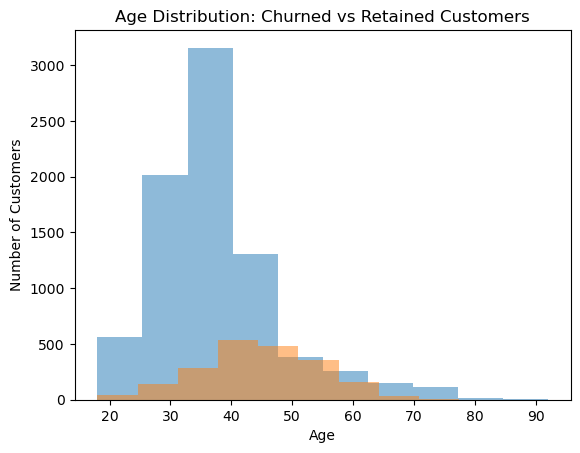

In [80]:
plt.figure()

plt.hist(data_churn[data_churn['Exited'] == 0]['Age'], alpha=0.5)
plt.hist(data_churn[data_churn['Exited'] == 1]['Age'], alpha=0.5)

plt.title("Age Distribution: Churned vs Retained Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.savefig(
    "Visuals/ChurnByAge.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


**Churn by Geography**

Exited        0    1
Geography           
France     4203  811
Germany    1695  814
Spain      2064  413


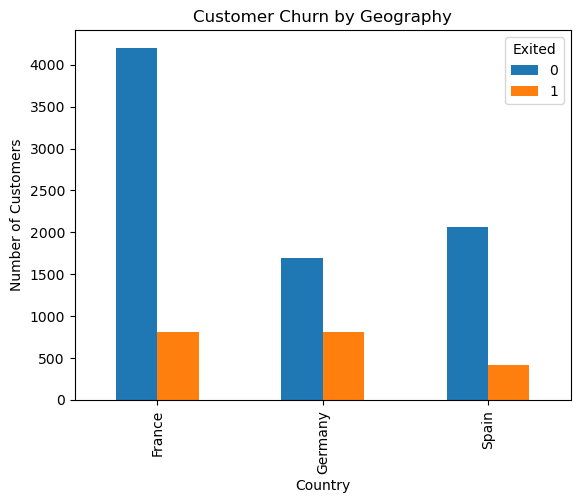

In [81]:
geo_churn = pd.crosstab(data_churn['Geography'], data_churn['Exited'])

print(geo_churn)

geo_churn.plot(kind='bar')

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.savefig(
    "Visuals/ChurnByGeography.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


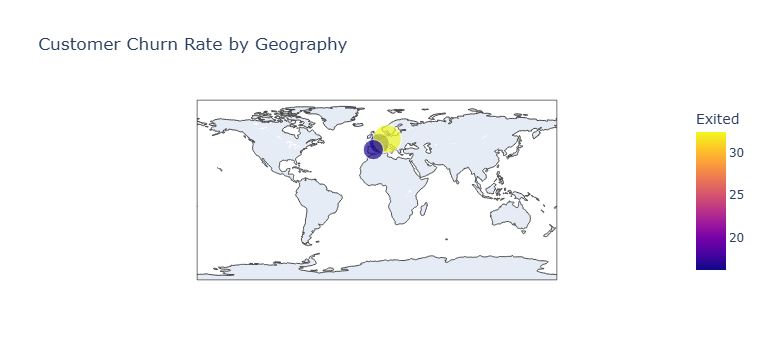

<Figure size 640x480 with 0 Axes>

In [82]:
fig = px.scatter_geo(
    geo_rate,
    locations="Geography",
    locationmode="country names",
    size="Exited",
    color="Exited",
    hover_name="Geography",
    title="Customer Churn Rate by Geography"
)
plt.savefig(
    "Visuals/Map.png",
    dpi=150,
    bbox_inches="tight"
)

fig.show()

**Churn By Active member status**

Exited             0     1
IsActiveMember            
0               3546  1303
1               4416   735


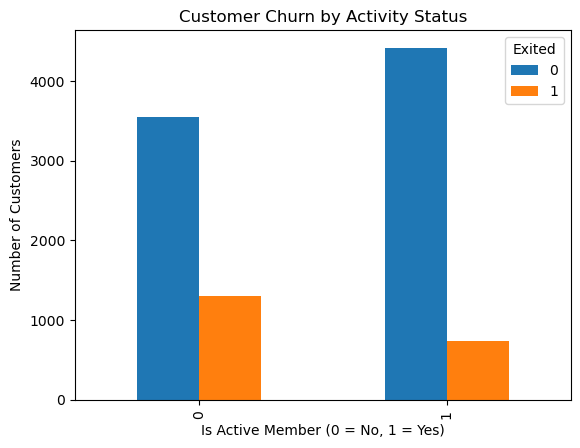

In [16]:
active_churn = pd.crosstab(data_churn['IsActiveMember'], data_churn['Exited'])

print(active_churn)

active_churn.plot(kind='bar')

plt.title("Customer Churn by Activity Status")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.savefig(
    "Visuals/ChurnByActmember.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


**Churn by Balance**

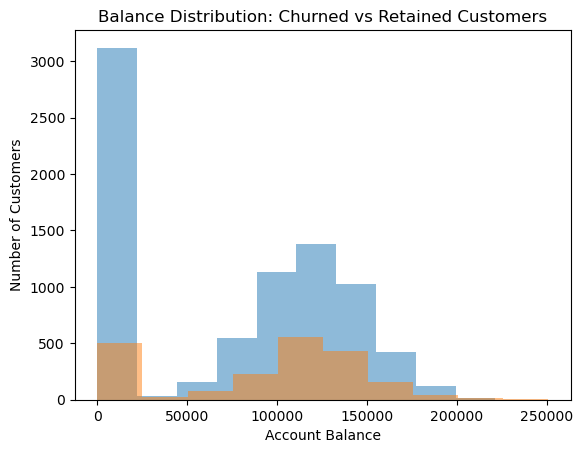

In [17]:
churned = data_churn[data_churn['Exited'] == 1]
stayed = data_churn[data_churn['Exited'] == 0]

plt.figure()

plt.hist(stayed['Balance'], alpha=0.5)
plt.hist(churned['Balance'], alpha=0.5)

plt.title("Balance Distribution: Churned vs Retained Customers")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")
plt.savefig(
    "Visuals/ChurnByBalance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


**Tenure by Churn**

In [18]:
pd.crosstab(
    data_churn["Tenure"],
    data_churn["Exited"]
)

Exited,0,1
Tenure,,
0,318,95
1,803,232
2,847,201
3,796,213
4,786,203
5,803,209
6,771,196
7,851,177
8,828,197


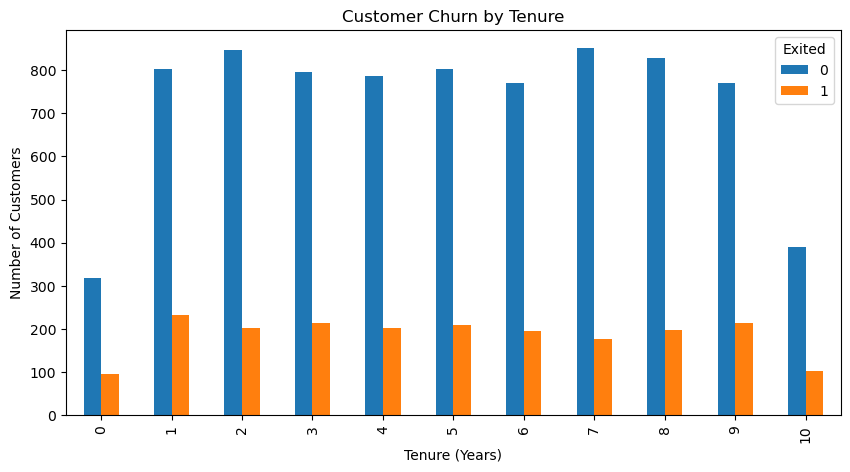

In [19]:
pd.crosstab(
    data_churn["Tenure"],
    data_churn["Exited"]
).plot(kind="bar", figsize=(10,5))

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Customers")
plt.savefig(
    "Visuals/ChurnByTenure.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

**Number of Products by Churn**

In [20]:
pd.crosstab(
    data_churn["NumOfProducts"],
    data_churn["Exited"]
)

Exited,0,1
NumOfProducts,,
1,3675,1409
2,4241,349
3,46,220
4,0,60


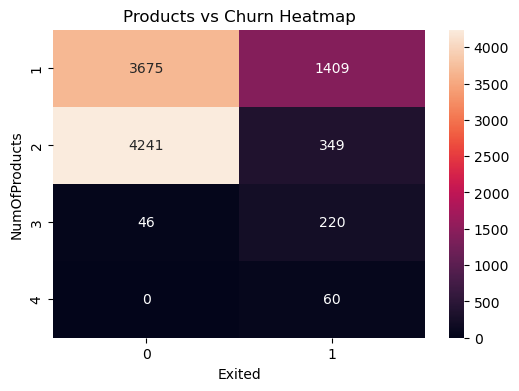

In [21]:
import seaborn as sns

cross = pd.crosstab(
    data_churn["NumOfProducts"],
    data_churn["Exited"]
)

plt.figure(figsize=(6,4))
sns.heatmap(cross, annot=True, fmt="d")
plt.savefig(
    "Visuals/ChurnByProduct.png",
    dpi=150,
    bbox_inches="tight"
)


plt.title("Products vs Churn Heatmap")
plt.show()

**Satisfaction Score by Churn**

In [22]:
pd.crosstab(
    data_churn["Satisfaction Score"],
    data_churn["Exited"]
)

Exited,0,1
Satisfaction Score,,
1,1545,387
2,1575,439
3,1641,401
4,1594,414
5,1607,397


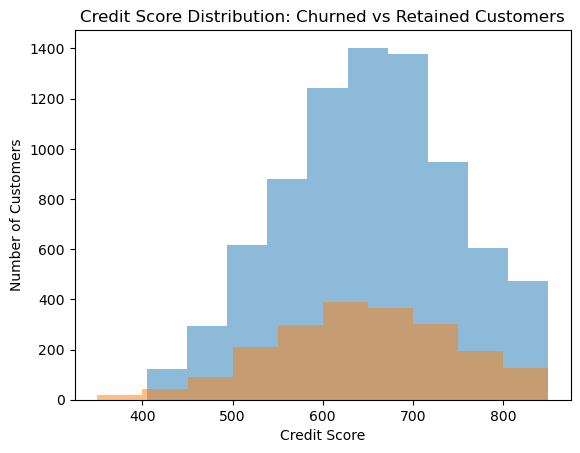

In [23]:
plt.figure()

plt.hist(data_churn[data_churn['Exited'] == 0]['CreditScore'], alpha=0.5)
plt.hist(data_churn[data_churn['Exited'] == 1]['CreditScore'], alpha=0.5)

plt.title("Credit Score Distribution: Churned vs Retained Customers")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.savefig(
    "Visuals/ChurnByRetained.png",
    dpi=150,
    bbox_inches="tight"
)


plt.show()


## Data Preprocessing

In [24]:
churn_clean.select_dtypes(include="object").columns

Index(['Geography', 'Gender', 'Card Type'], dtype='object')

In [25]:
#encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["Geography", "Gender", "Card Type"]:
    churn_clean[col] = le.fit_transform(churn_clean[col])

In [26]:
#verify
churn_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425


**Create Features and Target**

Features = customer information

Target = churn

In [27]:
X = churn_clean.drop("Exited", axis=1)

y = churn_clean["Exited"]

In [28]:
#Shapes
print(X.shape)
print(y.shape)

(10000, 14)
(10000,)


# MACHINES LEARNING

In [29]:
#Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
#verify

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 14)
X_test : (2000, 14)
y_train: (8000,)
y_test : (2000,)


In [31]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [32]:
#train model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
#Predictions
y_pred = model.predict(X_test)

In [34]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.999


In [35]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1606    1]
 [   1  392]]


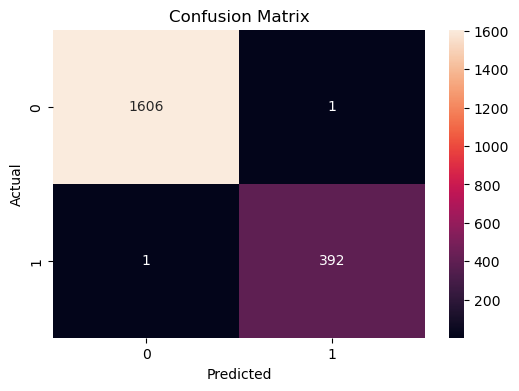

In [36]:
#Visualization
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(
    "Visuals/ConfusionMatrix.png",
    dpi=150,
    bbox_inches="tight"
)


plt.show()

**Feature Importance**

In [37]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
10            Complain    0.822939
3                  Age    0.054823
6        NumOfProducts    0.050133
8       IsActiveMember    0.014619
5              Balance    0.013688
0          CreditScore    0.008302
9      EstimatedSalary    0.008254
13        Point Earned    0.008162
1            Geography    0.004867
4               Tenure    0.004772
2               Gender    0.003271
11  Satisfaction Score    0.002926
12           Card Type    0.002342
7            HasCrCard    0.000903


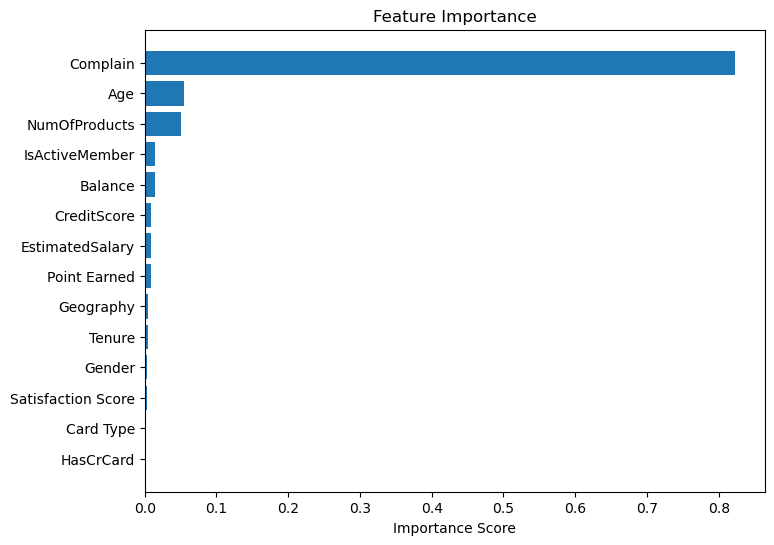

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.savefig(
    "Visuals/FeatureImportance.png",
    dpi=150,
    bbox_inches="tight"
)


plt.gca().invert_yaxis()

plt.show()

**Churn Probability**

In [39]:
churn_probability = model.predict_proba(X_test)

In [40]:
churn_probability = churn_probability[:,1]

In [41]:
results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred
results["Churn_Probability"] = churn_probability

results.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Actual,Predicted,Churn_Probability
6252,596,1,1,32,3,96709.07,2,0,0,41788.37,0,1,1,709,0,0,0.00
4684,623,0,1,43,1,0.00,2,1,1,146379.30,0,2,3,508,0,0,0.00
1731,601,2,0,44,4,0.00,2,1,0,58561.31,0,1,1,281,0,0,0.00
4742,506,1,1,59,8,119152.10,2,1,1,170679.74,0,2,3,979,0,0,0.01
4521,560,2,0,27,7,124995.98,1,1,1,114669.79,0,5,3,457,0,0,0.00


**High-Risk Customers**

In [42]:
high_risk = results.sort_values(
    by="Churn_Probability",
    ascending=False
)

high_risk.head(20)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Actual,Predicted,Churn_Probability
2750,481,0,0,57,9,0.00,3,1,1,169719.35,1,3,3,259,1,1,1.0
6911,705,1,0,54,3,125889.30,3,1,0,96013.50,1,2,2,674,1,1,1.0
5922,555,0,0,44,3,105770.70,3,1,0,60533.96,1,4,0,902,1,1,1.0
6428,627,1,0,39,5,124586.93,1,1,0,93132.61,1,2,0,265,1,1,1.0
8127,651,1,1,35,8,110067.71,1,1,0,127678.95,1,2,1,689,1,1,1.0
2932,688,0,0,54,9,0.00,1,1,0,191212.63,1,5,1,746,1,1,1.0
3032,495,2,0,45,3,89158.94,3,1,0,135169.76,1,1,2,284,1,1,1.0
1825,770,1,1,45,4,110765.68,1,1,0,26163.74,1,1,1,550,1,1,1.0
1068,594,0,1,57,6,0.00,1,1,0,19376.56,1,5,1,661,1,1,1.0
538,564,1,0,62,5,114931.35,3,0,1,18260.98,1,3,1,771,1,1,1.0


In [43]:
results.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

In [44]:
all_results = churn_clean.copy()

all_results["Predicted"] = model.predict(X)

all_results["Churn_Probability"] = model.predict_proba(X)[:,1]

all_results.to_csv(
    "customer_churn_predictions_full.csv",
    index=False
)